In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mercado selecionado: maduro out by january 31, 2026?

pergunta central da análise: Com base nos dados disponibilizados, é possível reconhecer padrões anormais de negociação que indiquem a atuação de usuários com informações privilegiadas?

Em primeiro lugar, para encontrar uma aposta para analisar, procuramos por registros de question que contenham o nome 'maduro' e ordenamos de forma decrescente em relação ao volume de trades. abaixo, os resultados encontrados:

query:\
select market_id, question, volume, created_at, end_date, closed\
from `even-continuity-441808-j0.polymarket_optimized.markets`\
where LOWER(event_title) like '%maduro%'\
order by volume DESC;

In [129]:
df = pd.read_csv("dados/apostas_com_maior_volume_maduro.csv")
df.head()

,market_id,question,volume,created_at,end_date,closed
0,516947,Maduro out in 2025?,3.464140e+07,2024-12-31 18:11:41.000000 UTC,2025-12-31 12:00:00.000000 UTC,1
1,1094682,Maduro in U.S. custody by January 31?,1.103407e+07,2026-01-03 07:47:51.000000 UTC,2026-01-31 00:00:00.000000 UTC,1
2,916440,"Maduro out by January 31, 2026?",1.096693e+07,2025-12-11 21:44:09.000000 UTC,2026-01-31 12:00:00.000000 UTC,1
3,663849,"Maduro out by November 30, 2025?",5.568345e+06,2025-11-03 22:41:17.000000 UTC,2025-11-30 12:00:00.000000 UTC,1
4,663850,"Maduro out by March 31, 2026?",3.793232e+06,2025-11-03 22:42:05.000000 UTC,2026-03-31 12:00:00.000000 UTC,1


Vamos considerar a pergunta de id='916440', 'Maduro out by January 31, 2026?', criada em 11/12/2025, criada cerca de 3 semanas antes da queda de Maduro, e finalizada em 31/01/2026. Dentre as apostas que podem ter beneficiado apostadores com informações privilegiadas sobre a captura de Maduro, essa é a com maior volume de negociações. Vale ressaltar que a pergunta de id='1094682' foi criada após a queda de Maduro, e portanto não cabe à análise que desejamos realizar.\

Nas células abaixo, são exibidas informações gerais da tabela markets sobre a aposta selecionada, bem como um gráfico com a evolução diária do valor investido, em dólares, nesse ativo.\
query:\
select *\
from `even-continuity-441808-j0.polymarket_optimized.markets`\
where market_id='916440'

In [130]:
df = pd.read_csv("dados/market_916440.csv")
df.head()

,market_id,question,slug,condition_id,token1,token2,answer1,answer2,closed,active,archived,outcome_prices,volume,event_id,event_slug,event_title,created_at,end_date,updated_at,neg_risk
0,916440,"Maduro out by January 31, 2026?",maduro-out-by-january-31-2026-318,0x580adc1327de9bf7c179ef5aaffa3377bb5cb252b7d6...,2491806774766175904872013560768793420917294570...,9859036369581097648975541433025819196678313717...,Yes,No,1,1,0,"['1', '0']",1.096693e+07,16180,maduro-out-in-2025,Maduro out by...?,2025-12-11 21:44:09.000000 UTC,2026-01-31 12:00:00.000000 UTC,2026-04-16 00:28:21.000000 UTC,0


In [131]:
daily_market_df = pd.read_csv("dados/daily_market_stats_916440.csv")
daily_market_df = daily_market_df.sort_values(by="trade_date").reset_index(drop=True)
daily_market_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   market_id          23 non-null     int64  
 1   event_title        23 non-null     str    
 2   trade_date         23 non-null     str    
 3   daily_trade_count  23 non-null     int64  
 4   daily_usd_volume   23 non-null     float64
 5   avg_trade_price    23 non-null     float64
 6   min_trade_price    23 non-null     float64
 7   max_trade_price    23 non-null     float64
dtypes: float64(4), int64(2), str(2)
memory usage: 2.2 KB


In [132]:
daily_market_df.head()

,market_id,event_title,trade_date,daily_trade_count,daily_usd_volume,avg_trade_price,min_trade_price,max_trade_price
0,916440,Maduro out by...?,2025-12-12,150,15608.03,0.513267,0.15,0.81
1,916440,Maduro out by...?,2025-12-13,184,39161.25,0.614185,0.20,0.80
2,916440,Maduro out by...?,2025-12-14,141,11256.14,0.421560,0.18,0.82
3,916440,Maduro out by...?,2025-12-15,177,33445.41,0.403955,0.15,0.85
4,916440,Maduro out by...?,2025-12-16,301,61234.44,0.440797,0.16,0.85


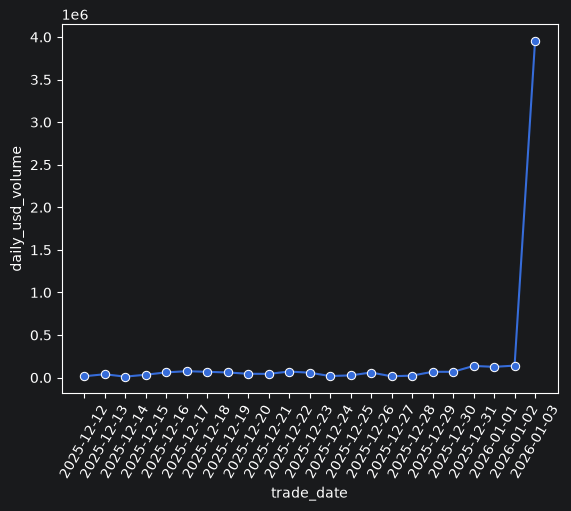

In [133]:
fig, ax = plt.subplots()
sns.lineplot(data=daily_market_df, x="trade_date", y="daily_usd_volume", marker="o")
ax.set_xticks(daily_market_df["trade_date"])
plt.xticks(rotation=60)
plt.show()

Como podemos observar na consulta abaixo, o último trade ocorreu por volta de 12:00 do dia 03/01/2026, sendo que Nicolás Maduro foi capturado por volta de 06:00 do dia 03/01/2026. Por esse motivo, vamos limitar esta análise às trades que ocorreram até o dia 02/01/2026.

query:\
SELECT MAX(trade_timestamp) AS ultimo_trade\
FROM `even-continuity-441808-j0.polymarket_optimized.trades`\
where trade_timestamp >= TIMESTAMP("2025-12-12")\
AND trade_timestamp < TIMESTAMP("2026-01-31") and market_id='916440'

In [134]:
last_trade = pd.read_csv("dados/ultimo_trade.csv")
last_trade

,ultimo_trade
0,2026-01-03 12:13:39.000000 UTC


In [135]:
daily_market_df.drop(index=22, inplace=True)

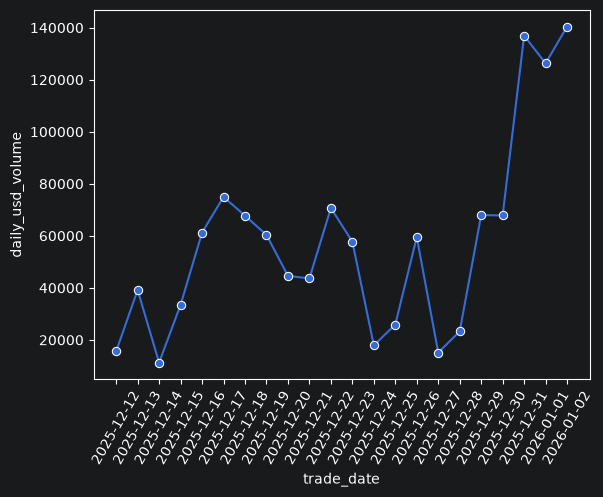

In [136]:
fig, ax = plt.subplots()
sns.lineplot(data=daily_market_df, x="trade_date", y="daily_usd_volume", marker="o")
ax.set_xticks(daily_market_df["trade_date"])
plt.xticks(rotation=60)
plt.show()

Com base no gráfico acima, podemos observar que o volume de dólares negociados do ativo dobrou nos 3 dias que antecederam a queda do presidente Nicolás Maduro, o que indica um aumento considerável da movimentação do mercado.

A partir de agora, vamos analisar a evolução diária das negociações, separadas em apostas a favor (token1) e apostas contra (token2), e procurar por tendências e viéses. Para isso, foi feita uma consulta sobre a tabela trades do banco optimized. Os dados foram agrupados por dia e por token. A coluna price_avg representa a média da probabilidade implícita para aquela aposta em determinado dia. A coluna usd_sum contém o somatório das apostas em dólar naquele dia e a coluna token_sum, por sua vez, o somatório dos tokens apostados. A consulta foi limitada às 6:00 UTC do dia 03/01/2026, pouco antes da captura de Maduro.

query:\
SELECT\
    DATE(trade_timestamp) AS dia,\
    nonusdc_side,\
    avg(usd_amount) AS price_avg,\
    sum(usd_amount) AS usd_sum,\
    sum(token_amount) AS token_sum\
FROM `even-continuity-441808-j0.polymarket_optimized.trades`\
WHERE\
    market_id = '916440'\
    AND trade_timestamp >= TIMESTAMP('2025-12-12 00:00:00 UTC')\
    AND trade_timestamp < TIMESTAMP('2026-01-03 06:00:00 UTC')\
GROUP BY\
    dia,\
    nonusdc_side\
ORDER BY\
    dia,\
    nonusdc_side;

In [137]:
daily_trades_df = pd.read_csv("dados/apostas_diarias_sim_e_nao_916440.csv")
daily_trades_df.head(6)

,dia,nonusdc_side,price_avg,usd_sum,token_sum
0,2025-12-12,token1,0.198551,1006.94,5139.20
1,2025-12-12,token2,0.781358,14601.09,18496.84
2,2025-12-13,token1,0.205000,1266.46,6306.88
3,2025-12-13,token2,0.784154,37894.79,48368.75
4,2025-12-14,token1,0.189659,3509.59,18655.38
5,2025-12-14,token2,0.806604,7746.55,9599.92


Abaixo, separamos as apostas diárias em token1 (apostas a favor da ocorrência) e token2 (apostas contra a ocorrência).

In [138]:
token1_trades_df = daily_trades_df[daily_trades_df["nonusdc_side"]=="token1"].reset_index(drop=True)
token2_trades_df = daily_trades_df[daily_trades_df["nonusdc_side"]=="token2"].reset_index(drop=True)
token1_trades_df

,dia,nonusdc_side,price_avg,usd_sum,token_sum
0,2025-12-12,token1,0.198551,1006.94,5139.20
1,2025-12-13,token1,0.205000,1266.46,6306.88
2,2025-12-14,token1,0.189659,3509.59,18655.38
3,2025-12-15,token1,0.162832,5376.39,32974.54
4,2025-12-16,token1,0.170852,9886.52,55292.22
5,2025-12-17,token1,0.201176,5027.46,23773.41
6,2025-12-18,token1,0.201069,8407.45,40220.80
7,2025-12-19,token1,0.163228,16207.54,100987.03
8,2025-12-20,token1,0.120467,4184.91,36152.02
9,2025-12-21,token1,0.132273,3172.70,23683.99


Análise da evolução da média de prices para o token1, em azul e para o token2, em vermelho.

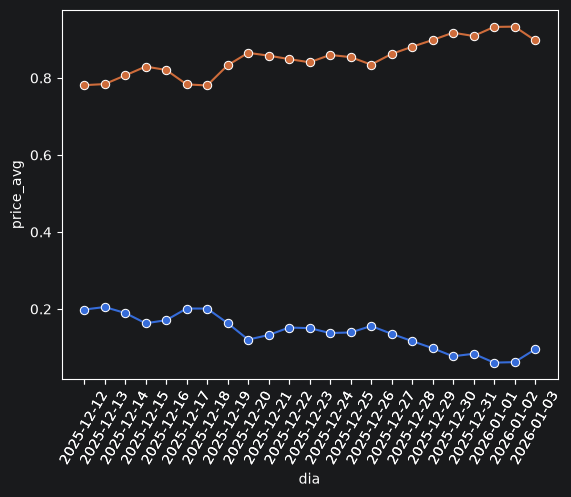

In [139]:
fig, ax = plt.subplots()
sns.lineplot(data=token1_trades_df, x="dia", y="price_avg", marker="o")
sns.lineplot(data=token2_trades_df, x="dia", y="price_avg", marker="o")
ax.set_xticks(daily_trades_df["dia"])
plt.xticks(rotation=60)
plt.show()

Abaixo, análise da evolução do valor em dólares apostado para o token1, em azul e para o token2, em vermelho.

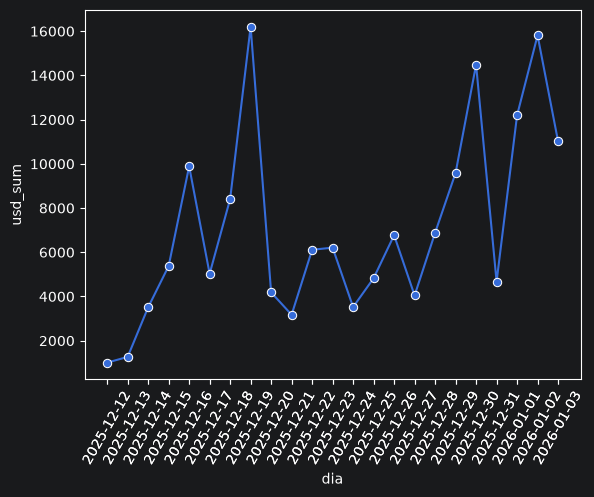

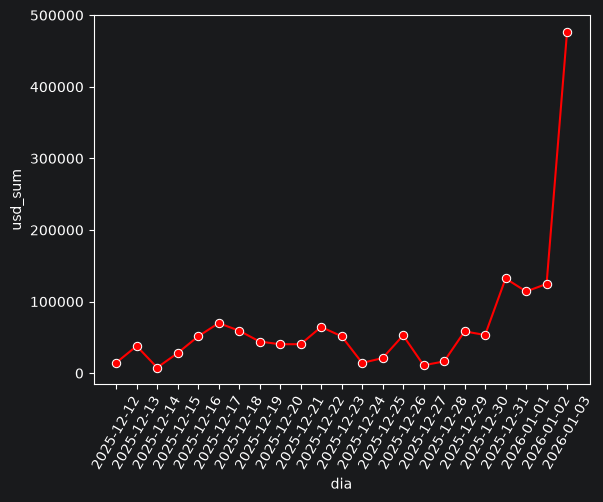

In [140]:
fig, ax = plt.subplots()
sns.lineplot(data=token1_trades_df, x="dia", y="usd_sum", marker="o")
ax.set_xticks(daily_trades_df["dia"])
plt.xticks(rotation=60)
plt.show()

sns.lineplot(data=token2_trades_df, x="dia", y="usd_sum", marker="o", color="red")
ax.set_xticks(daily_trades_df["dia"])
plt.xticks(rotation=60)
plt.show()

O que chama a atenção nos gráficos acima é o valor total de negociação do token2 nos horários que antecederam a captura de Maduro. É possível que pessoas com informações privilegiadas tenham vendido todos os seus ativos desse token pouco antes da ocorrência.

Para verificar se de fato houve concentração na negociação do token2, vamos analisar o valor máximo em dólares pelo qual esse ativo foi negociado a cada dia.

query:\
SELECT\
    DATE(trade_timestamp) AS dia,\
    nonusdc_side,\
    max(usd_amount) AS usd_sum,\
FROM `even-continuity-441808-j0.polymarket_optimized.trades`\
WHERE\
    market_id = '916440'\
    AND trade_timestamp >= TIMESTAMP('2025-12-12 00:00:00 UTC')\
    AND trade_timestamp < TIMESTAMP('2026-01-03 06:00:00 UTC')\
GROUP BY\
    dia,\
    nonusdc_side\
ORDER BY\
    dia,\
    nonusdc_side;

In [141]:
max_bet_df = pd.read_csv("dados/maximo_apostado_916440.csv")
max_bet_df

,dia,nonusdc_side,usd_sum
0,2025-12-12,token1,144.97
1,2025-12-12,token2,5756.46
2,2025-12-13,token1,448.89
3,2025-12-13,token2,10270.00
4,2025-12-14,token1,441.11
5,2025-12-14,token2,1809.59
6,2025-12-15,token1,800.00
7,2025-12-15,token2,8000.00
8,2025-12-16,token1,2764.55
9,2025-12-16,token2,8200.00


In [142]:
token2_max_df = max_bet_df[max_bet_df["nonusdc_side"]=="token2"].reset_index(drop=True)
token2_max_df

,dia,nonusdc_side,usd_sum
0,2025-12-12,token2,5756.46
1,2025-12-13,token2,10270.00
2,2025-12-14,token2,1809.59
3,2025-12-15,token2,8000.00
4,2025-12-16,token2,8200.00
5,2025-12-17,token2,7163.06
6,2025-12-18,token2,9327.22
7,2025-12-19,token2,14511.31
8,2025-12-20,token2,5280.00
9,2025-12-21,token2,2148.55


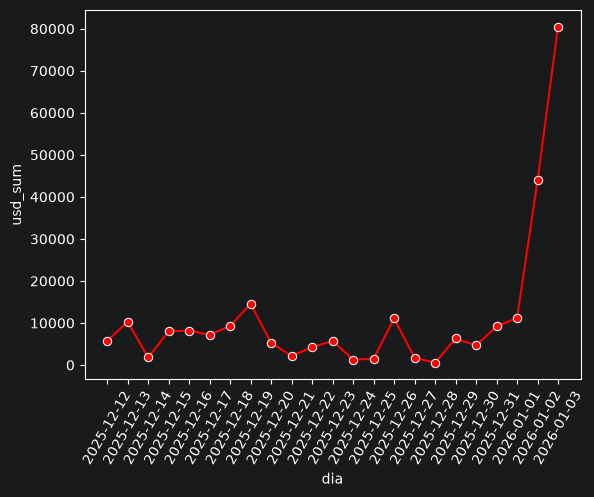

np.float64(11059.410434782607)

In [143]:
fig, ax = plt.subplots()
sns.lineplot(data=token2_max_df, x="dia", y="usd_sum", marker="o", color="red")
ax.set_xticks(token2_max_df["dia"])
plt.xticks(rotation=60)
plt.show()
np.average(token2_max_df["usd_sum"])

O gráfico acima nos permite concluir que cerca de um quinto das vendas totais do token2 foi realizada em uma única negociação, que foi cerca de 8 vezes maior do que a média dos máximos das negociações diárias desse ativo.

Agora, vamos analisar a evolução diária do total de tokens comprados e vendidos pelo usuário que mais negociou o token 1 (a favor da queda).

WITH all_users AS (\
    SELECT\
        maker AS usuario,\
        token_amount\
    FROM `even-continuity-441808-j0.polymarket_optimized.trades`\
    WHERE market_id = '916440'\
      AND nonusdc_side = 'token1'\
        AND trade_timestamp >= TIMESTAMP('2025-12-12 00:00:00 UTC')\
        AND trade_timestamp < TIMESTAMP('2026-01-03 06:00:00 UTC')\
    UNION ALL\
\
    SELECT\
        taker AS usuario,\
        token_amount\
    FROM `even-continuity-441808-j0.polymarket_optimized.trades`\
    WHERE market_id = '916440'\
      AND nonusdc_side = 'token1'\
      AND trade_timestamp >= TIMESTAMP('2025-12-12 00:00:00 UTC')\
        AND trade_timestamp < TIMESTAMP('2026-01-03 06:00:00 UTC')\
),\
\
top_user AS (\
    SELECT usuario\
    FROM all_users\
    GROUP BY usuario\
    ORDER BY SUM(token_amount) DESC\
    LIMIT 1\
)\
\
SELECT\
    DATE(trade_timestamp) AS dia,\
\
    SUM(\
        CASE\
            WHEN maker = (SELECT usuario FROM top_user)\
                 AND maker_direction = 'SELL'\
            THEN token_amount\
\
            WHEN taker = (SELECT usuario FROM top_user)\
                 AND taker_direction = 'SELL'\
            THEN token_amount\
\
            ELSE 0\
        END\
    ) AS total_vendido,\
\
    SUM(\
        CASE\
            WHEN maker = (SELECT usuario FROM top_user)\
                 AND maker_direction = 'BUY'\
            THEN token_amount\
\
            WHEN taker = (SELECT usuario FROM top_user)\
                 AND taker_direction = 'BUY'\
            THEN token_amount\
\
            ELSE 0\
        END\
    ) AS total_comprado\
\
FROM `even-continuity-441808-j0.polymarket_optimized.trades`\
WHERE\
    market_id = '916440'\
    AND nonusdc_side = 'token1'\
    AND (\
        maker = (SELECT usuario FROM top_user)\
        OR taker = (SELECT usuario FROM top_user)\
    )\
    AND trade_timestamp >= TIMESTAMP('2025-12-12 00:00:00 UTC')\
    AND trade_timestamp < TIMESTAMP('2026-01-03 06:00:00 UTC')\
GROUP BY dia\
ORDER BY dia;

In [147]:
buy_sell_df = pd.read_csv("dados/top_user_compras_vendas.csv")
buy_sell_df

,dia,total_vendido,total_comprado
0,2025-12-12,0.00,1877.38
1,2025-12-13,0.00,1763.47
2,2025-12-14,0.00,5343.56
3,2025-12-15,0.00,6665.98
4,2025-12-16,0.00,2577.94
5,2025-12-17,0.00,3332.99
6,2025-12-19,0.00,4444.00
7,2025-12-25,0.00,2222.00
8,2025-12-28,0.00,6665.78
9,2025-12-29,0.00,26440.66


In [145]:
np.average(buy_sell_df["total_comprado"])
np.max(buy_sell_df["total_comprado"])

np.float64(53608.88)

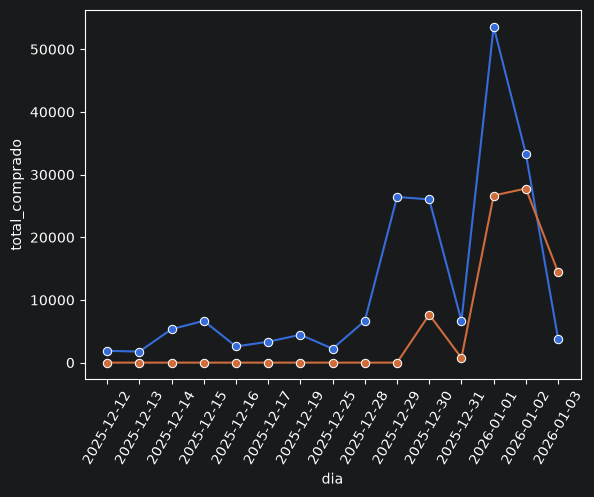

In [146]:
fig, ax = plt.subplots()
sns.lineplot(data=buy_sell_df, x="dia", y="total_comprado", marker="o")
sns.lineplot(data=buy_sell_df, x="dia", y="total_vendido", marker="o")
ax.set_xticks(buy_sell_df["dia"])
plt.xticks(rotation=60)
plt.show()

Com base no gráfico acima, podemos observar que nos 2 dias que antecederam a captura de Maduro, o usuário que mais negociou o token 1 fez a maior quantidade de compras de ativos a favor da queda de Maduro. O id desse usuário é 0xb6beD94E75c333daE24eB9c80b3feF47eF3cfcFE.

Analisando agora o total de compras e vendas do token 2 pelo usuário que mais negociou esse ativo, obtemos o resultado abaixo:

In [149]:
top_user_token2_df = pd.read_csv("dados/top_user_token2.csv")
top_user_token2_df

,dia,total_vendido,total_comprado
0,2025-12-31,9206.33,0.0
1,2026-01-01,50628.06,0.0
2,2026-01-02,53798.06,0.0
3,2026-01-03,236007.81,0.0


Os dados acima apontam que um único usuário realizou apenas vendas do ativo que apostava contra a queda de Maduro, e por valores extremamente altos, poucos dias antes da ocorrência. O id desse usuário é 0x31a56e9E690c621eD21De08Cb559e9524Cdb8eD9. Nesse cenário, surge um questionamento: como é possível que um usuário tenha feito apenas vendas de um ativo, sem antes ter realizado compras do mesmo? Uma possível resposta é que, no Polymarket, existe a possibilidade de um usuário fazer transferência de ativos de uma conta para outra, principalmente por questões de estratégia de apostas ou organização dos ativos.

Apesar de não ser possível afirmar categoricamente, é possível que esses usuários tenham recebido informações privilegiadas e, dessa maneira, tenham aumentado significativamente a quantidade de ativos comprados e vendidos, para, evidentemente, realizarem maior lucro.

## Alertas 🚨

#### Alerta 1
Com base nas análises anteriores, identificamos que um grande volume de compras do token1 (a favor da queda de Maduro) foi feito, nos três dias que antecederam a queda, pelo usuário que mais negociou esse token. Assim, o primeiro alerta tem por objetivo exibir os usuários que compraram o token1 entre os dias 01/01/2026 e 03/01/2026 em uma quantidade pelo menos 5 vezes maior do que o máximo de suas compras diárias desse token nos dias anteriores (entre 12/12/2026 e 31/12/2026). O resultado está exibido na célula abaixo.

WITH compras_diarias AS (\
\
    -- Compras de token1 por usuário por dia\
    SELECT\
        usuario,\
        DATE(trade_timestamp) AS dia,\
        SUM(token_amount) AS comprado_dia\
\
    FROM (\
\
        SELECT\
            maker AS usuario,\
            trade_timestamp,\
            token_amount\
        FROM `even-continuity-441808-j0.polymarket_optimized.trades`\
        WHERE market_id = '916440'\
          AND nonusdc_side = 'token1'\
          AND maker_direction = 'BUY'\
\
        UNION ALL\
\
        SELECT\
            taker AS usuario,\
            trade_timestamp,\
            token_amount\
        FROM `even-continuity-441808-j0.polymarket_optimized.trades`\
        WHERE market_id = '916440'\
          AND nonusdc_side = 'token1'\
          AND taker_direction = 'BUY'\
\
    )\
\
    WHERE trade_timestamp >= TIMESTAMP('2025-12-12 00:00:00 UTC')\
      AND trade_timestamp < TIMESTAMP('2026-01-03 06:00:00 UTC')\
\
    GROUP BY usuario, dia\
),\
\
\
-- Máximo diário de compras antes do evento\
historico AS (\
\
    SELECT\
        usuario,\
        MAX(comprado_dia) AS max_compra_diaria_anterior\
\
    FROM compras_diarias\
\
    WHERE dia BETWEEN '2025-12-12' AND '2025-12-31'\
\
    GROUP BY usuario\
),\
\
\
-- Compras nos dias do evento\
compras_evento AS (\
\
    SELECT\
        c.usuario,\
        c.dia,\
        c.comprado_dia,\
        h.max_compra_diaria_anterior\
\
    FROM compras_diarias c\
\
    JOIN historico h\
      ON c.usuario = h.usuario\
\
    WHERE \
        (\
            c.dia = '2026-01-01'\
            OR c.dia = '2026-01-02'\
            OR (\
                c.dia = '2026-01-03'\
                AND c.comprado_dia IS NOT NULL\
            )\
        )\
\
)\
\
\
SELECT\
    usuario,\
    dia,\
    comprado_dia,\
    max_compra_diaria_anterior,\
    SAFE_DIVIDE(\
        comprado_dia,\
        max_compra_diaria_anterior\
    ) AS multiplicador\
\
FROM compras_evento\
\
WHERE comprado_dia >= 5 * max_compra_diaria_anterior\
\
ORDER BY multiplicador DESC;\

In [150]:
alerta1_df = pd.read_csv("dados/alerta_1_resultado.csv")
alerta1_df

,usuario,dia,comprado_dia,max_compra_diaria_anterior,multiplicador
0,0x7b2E0880807Cc19F553c9569c873F23a770b36fd,2026-01-02,2698.01,15.58,173.171374
1,0x839876E0574ccAdaAd39A3d97DA154E0BD56749a,2026-01-02,3400.00,100.00,34.000000
2,0x51126EB7499Dd48e45e1A9DB830a451faC8e6AeF,2026-01-01,285.00,31.86,8.945386
3,0xC40e934C6aEfc54fa1fC1255324a0Ac79398EbF5,2026-01-01,128.60,15.00,8.573333
4,0xFC70FDfD803ce350eF14A536C81EaD38014D4Aed,2026-01-01,14049.23,1642.08,8.555752
5,0xcf6A714618a328C608a1c70Cb62a31a6BEf3F9d0,2026-01-01,8339.19,1019.36,8.180810
6,0x3078DB4A9737866b4d6529F655025B3A20f80389,2026-01-03,3349.91,417.02,8.032972
7,0x31a56e9E690c621eD21De08Cb559e9524Cdb8eD9,2026-01-02,36549.23,5413.00,6.752121
8,0xFF9152AC8Cb6260419EA8940248177083aCeAB3a,2026-01-01,600.00,100.00,6.000000
9,0xEb8984BD4aAd72274F170Bfc71EF4FA21a4646f1,2026-01-01,181.72,34.86,5.212851


#### Alerta 2
A segunda movimentação suspeita identificada foi a venda de ativos do token2 de maneira concentrada nos últimos 3 dias que antecederam a queda de Maduro. Dessa forma, o alerta 2 tem por objetivo identificar os usuários que venderam o ativo do token2 em um volume pelo menos 10 vezes maior do que a média diária de vendas nos dias anteriores (12/12/2025-31/12/2025).\
O resultado da consulta está exibido abaixo.

query:\
WITH vendas_diarias AS (\
\
    SELECT\
        usuario,\
        DATE(trade_timestamp) AS dia,\
        SUM(token_amount) AS vendido_dia\
    FROM (\
\
        SELECT\
            maker AS usuario,\
            trade_timestamp,\
            token_amount\
        FROM `even-continuity-441808-j0.polymarket_optimized.trades`\
        WHERE market_id = '916440'\
          AND nonusdc_side = 'token2'\
          AND maker_direction = 'SELL'\
\
        UNION ALL\
\
        SELECT\
            taker AS usuario,\
            trade_timestamp,\
            token_amount\
        FROM `even-continuity-441808-j0.polymarket_optimized.trades`\
        WHERE market_id = '916440'\
          AND nonusdc_side = 'token2'\
          AND taker_direction = 'SELL'\
\
    )\
\
    WHERE trade_timestamp >= TIMESTAMP('2025-12-12 00:00:00 UTC')\
      AND trade_timestamp < TIMESTAMP('2026-01-03 06:00:00 UTC')\
\
    GROUP BY usuario, dia\
),\
\
historico AS (\
\
    SELECT\
        usuario,\
        AVG(vendido_dia) AS media_vendas_diarias\
    FROM vendas_diarias\
    WHERE dia BETWEEN '2025-12-12' AND '2025-12-31'\
    GROUP BY usuario\
),\
\
evento AS (\
\
    SELECT\
        usuario,\
        SUM(vendido_dia) AS vendido_periodo\
    FROM vendas_diarias\
    WHERE dia >= '2026-01-01'\
    GROUP BY usuario\
)\
\
SELECT\
    e.usuario,\
    e.vendido_periodo,\
    h.media_vendas_diarias,\
    SAFE_DIVIDE(e.vendido_periodo, h.media_vendas_diarias) AS multiplicador\
FROM evento e\
JOIN historico h\
  ON e.usuario = h.usuario\
WHERE e.vendido_periodo >= 5 * h.media_vendas_diarias\
ORDER BY multiplicador DESC;


In [152]:
alerta2_df = pd.read_csv("dados/alerta_2_resultado.csv")
alerta2_df

,usuario,vendido_periodo,media_vendas_diarias,multiplicador
0,0x8204C2803f9B69E6a623aC70c92a049699eD56EA,2825.83,25.81,109.485858
1,0x31a56e9E690c621eD21De08Cb559e9524Cdb8eD9,340433.93,9206.33,36.978245
2,0x9Ed9FB24166D7AAe9EC0F8Eef267c46CB34eF365,11583.08,394.22,29.382274
3,0x8b848FCD84a1dfb6D056eA135f39BB3f95b85061,400.00,20.00,20.000000
4,0xf1e3FD550705867e98fb245ceC8DA2074Ac91647,14.29,1.08,13.231481
